In [1]:
import sys
import os
import types
from pathlib import Path

# --- PARCHE DEFINITIVO PARA PKG_RESOURCES ---
try:
    import pkg_resources
except ImportError:
    # Creamos un reemplazo en memoria para que ydata-profiling no se rompa
    mock_pkg = types.ModuleType("pkg_resources")
    mock_pkg.get_distribution = lambda x: types.SimpleNamespace(version="0.0.0")
    sys.modules["pkg_resources"] = mock_pkg
    print("✅ Compatibilidad pkg_resources activada")

# --- IMPORTS DE LIBRERÍAS EXTERNAS ---
from ydata_profiling import ProfileReport
import pandas as pd

# --- CONFIGURACIÓN DE RUTA DEL PROYECTO ---
root_path = Path.cwd().parent
if str(root_path) not in sys.path:
    sys.path.append(str(root_path))

# --- IMPORTS DE TU CARPETA SRC ---
try:
    from src.data import load_raw, validate_schema, create_features
    from src.features import select_features_by_iv, build_woe_tables, transform_woe
    from src.models import train_all_models, evaluate_models, save_model
    from src.metrics import auc_roc, costo_total, calcular_gini, transformar_a_score
    print("✅ Módulos del proyecto (src) cargados")
except Exception as e:
    print(f"⚠️ Nota: Algunos módulos de src no cargaron (revisa si instalaste xgboost): {e}")

✅ Compatibilidad pkg_resources activada


/var/folders/2n/vvvh68bs7s91q3zc0tz0ghb00000gn/T/ipykernel_56141/3856786017.py:17: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


✅ Módulos del proyecto (src) cargados


In [ ]:

import sys
import os

print(f"Versión de Python: {sys.version}")
print(f"Ruta del ejecutable: {sys.executable}")
print(f"¿Dónde busca librerías?: {sys.path}")

try:
    import pkg_resources
    print("✅ pkg_resources encontrado")
except ImportError:
    print("❌ pkg_resources NO encontrado")

Versión de Python: 3.11.15 (main, Apr 14 2026, 14:45:51) [Clang 22.1.3 ]
Ruta del ejecutable: /Users/alejandroalvear/Documents/Alejandro/Desarrollo/Finanzas/MachineLearning/credit_scoring_alvear/.venv/bin/python
¿Dónde busca librerías?: ['/Users/alejandroalvear/.local/share/uv/python/cpython-3.11.15-macos-aarch64-none/lib/python311.zip', '/Users/alejandroalvear/.local/share/uv/python/cpython-3.11.15-macos-aarch64-none/lib/python3.11', '/Users/alejandroalvear/.local/share/uv/python/cpython-3.11-macos-aarch64-none/lib/python3.11/lib-dynload', '', '/Users/alejandroalvear/Documents/Alejandro/Desarrollo/Finanzas/MachineLearning/credit_scoring_alvear/.venv/lib/python3.11/site-packages', '/Users/alejandroalvear/Documents/Alejandro/Desarrollo/Finanzas/MachineLearning/credit_scoring_alvear']
✅ pkg_resources encontrado


In [4]:
# 2 Carga del dataset (asegúrate de que el CSV esté en data/raw/)
df_raw = load_raw("../data/raw/bankloan.csv")

# Validación del esquema
validate_schema(df_raw)

# Creación de features e ingeniería básica
df = create_features(df_raw)
print(f"Dataset cargado y validado. Dimensiones: {df.shape}")



Dataset cargado y validado. Dimensiones: (1489, 12)


In [14]:
bankloan_data = load_raw("../data/raw/Bankloan.csv", sep=",")
profile = ProfileReport(bankloan_data, title="Pandas Profiling Report Bankloan")

NameError: name 'ProfileReport' is not defined

In [5]:
#Celda 3: Split y Selección de Features por IV
from sklearn.model_selection import train_test_split

# Split de datos
X = df.drop(columns=["Default"])
y = df["Default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Selección de variables basada en Information Value
features_sel = select_features_by_iv(X_train.assign(Default=y_train), target="Default", threshold=0.1)
print(f"Features seleccionadas (IV >= 0.1): {features_sel}")

Features seleccionadas (IV >= 0.1): ['Age', 'Employ', 'Address', 'Income', 'Leverage', 'Creddebt', 'MonthlyLoad', 'OthDebtRatio']


In [6]:
#Celda 4: Transformación WoE
# Construcción de tablas WoE usando solo el set de entrenamiento
woe_tables = build_woe_tables(X_train.assign(Default=y_train), features_sel, target="Default")

# Transformación de ambos sets (Train y Test)
X_train_woe = transform_woe(X_train[features_sel], woe_tables)
X_test_woe  = transform_woe(X_test[features_sel],  woe_tables)

X_train_woe.head()

,Age_woe,Employ_woe,Address_woe,Income_woe,Leverage_woe,Creddebt_woe,MonthlyLoad_woe,OthDebtRatio_woe
1110,-0.066344,0.234242,-0.320245,-0.051221,-1.573703,-0.413745,-1.669847,-1.248820
1052,0.661329,0.234242,0.248484,0.194062,0.909370,0.265013,0.909370,0.434912
1151,-0.215675,-1.067792,-0.320245,-0.218413,0.483702,-0.003593,0.534003,-0.243106
242,0.168736,-0.813396,0.186761,0.194062,-0.812546,-0.732503,-1.002675,-0.243106
1169,-0.066344,-0.140452,-0.320245,0.194062,-0.812546,-0.190462,-0.923211,-0.243106


In [7]:
print("Nulos en Train WoE:", X_train_woe.isna().sum().sum())
print("Nulos en Test WoE:", X_test_woe.isna().sum().sum())

Nulos en Train WoE: 0
Nulos en Test WoE: 0


In [8]:
#Celda 5: Entrenamiento y Evaluación
# Entrenamiento de todos los modelos definidos en src/models.py
models = train_all_models(X_train_woe, y_train)

# Ranking de modelos por AUC
tabla_auc = evaluate_models(models, X_test_woe, y_test)
display(tabla_auc)

,Modelo,AUC
0,Random Forest,0.783797
1,XGBoost,0.776589
2,Logistic Regression,0.765837


In [10]:
#Celda 6: Serialización del Mejor Modelo (Parte 5)
# Selección del mejor modelo según el ranking
mejor_nombre = tabla_auc.iloc[0]["Modelo"]
mejor_modelo  = models[mejor_nombre]

# Construcción de metadata dinámica
metadata = {
    "model_name":        mejor_nombre,
    "version":           "1.0",
    "author":            "Alvear",  # Tu apellido
    "dataset":           "data/raw/bankloan.csv",
    "n_train_samples":   int(len(y_train)),
    "n_test_samples":    int(len(y_test)),
    "features_selected": [f"{f}_woe" for f in features_sel],
    "hyperparameters":   mejor_modelo.get_params(),
    "metrics": {
        "auc_test": round(auc_roc(mejor_modelo, X_test_woe, y_test), 4),
        "costo_total_test": int(costo_total(y_test.values, mejor_modelo.predict_proba(X_test_woe)[:, 1], umbral=0.5)),
    },
}

# Guardado en disco
save_model(mejor_modelo, path="../models/baseline_v1", metadata=metadata)
print(f"Modelo {mejor_nombre} serializado con éxito en models/baseline_v1/")

Modelo Random Forest serializado con éxito en models/baseline_v1/


In [11]:
#Celda de Verificación (Bonus Parte 5)
import json
from pathlib import Path

metadata_path = Path("../models/baseline_v1/metadata.json")
with open(metadata_path) as f:
    meta = json.load(f)
print(json.dumps(meta, indent=2))

{
  "model_name": "Random Forest",
  "version": "1.0",
  "author": "Alvear",
  "dataset": "data/raw/bankloan.csv",
  "n_train_samples": 1191,
  "n_test_samples": 298,
  "features_selected": [
    "Age_woe",
    "Employ_woe",
    "Address_woe",
    "Income_woe",
    "Leverage_woe",
    "Creddebt_woe",
    "MonthlyLoad_woe",
    "OthDebtRatio_woe"
  ],
  "hyperparameters": {
    "bootstrap": true,
    "ccp_alpha": 0.0,
    "class_weight": null,
    "criterion": "gini",
    "max_depth": 6,
    "max_features": "sqrt",
    "max_leaf_nodes": null,
    "max_samples": null,
    "min_impurity_decrease": 0.0,
    "min_samples_leaf": 1,
    "min_samples_split": 2,
    "min_weight_fraction_leaf": 0.0,
    "monotonic_cst": null,
    "n_estimators": 200,
    "n_jobs": null,
    "oob_score": false,
    "random_state": 42,
    "verbose": 0,
    "warm_start": false
  },
  "metrics": {
    "auc_test": 0.7838,
    "costo_total_test": 29000
  },
  "saved_at": "2026-05-05"
}


Gini del Modelo: 0.5676
Score Promedio: 511 puntos


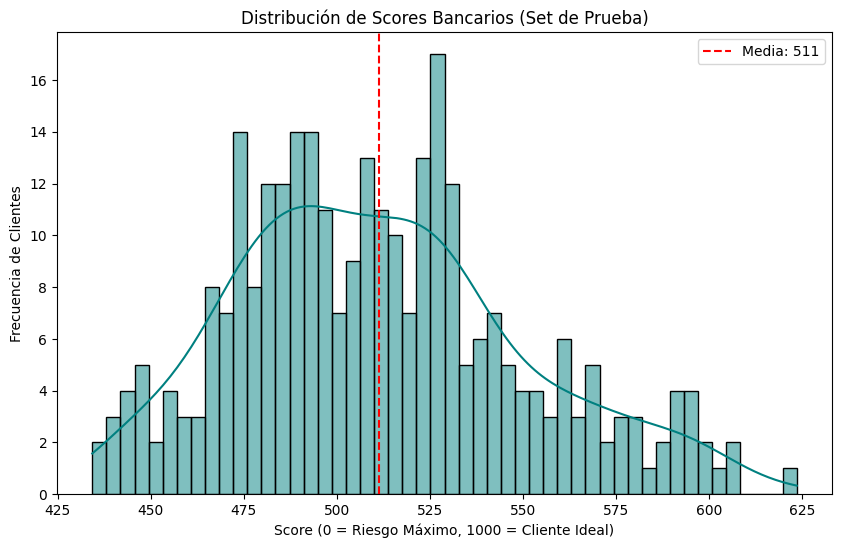

In [12]:
# Aplicar al set de prueba con el modelo campeón (Random Forest)
import numpy as np
probs_test = models["Random Forest"].predict_proba(X_test_woe)[:, 1]
scores_test = [transformar_a_score(p) for p in probs_test]

print(f"Gini del Modelo: {calcular_gini(0.7838):.4f}")
print(f"Score Promedio: {np.mean(scores_test):.0f} puntos")

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(scores_test, bins=50, kde=True, color='teal')
plt.axvline(np.mean(scores_test), color='red', linestyle='--', label=f'Media: {np.mean(scores_test):.0f}')
plt.title("Distribución de Scores Bancarios (Set de Prueba)")
plt.xlabel("Score (0 = Riesgo Máximo, 1000 = Cliente Ideal)")
plt.ylabel("Frecuencia de Clientes")
plt.legend()
plt.show()

